In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.spatial import cKDTree
import os
import fiona
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
meteo_doubs = gpd.read_file("../data/meteo/meteostat_doubs.csv")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

doubs_data = doubs_data.sort_values('date_debut')
meteo_doubs = meteo_doubs.sort_values('creneau')

doubs_meteo = pd.merge_asof(
    doubs_data,
    meteo_doubs,
    left_on='date_debut',
    right_on='creneau',
    direction='nearest',
    suffixes=('', '_meteo')
)

tree = cKDTree(meteo_doubs[['latitude', 'longitude']].values)
distances, indices = tree.query(doubs_meteo[['centroid_lat', 'centroid_lon']].values)

cols_to_keep = [col for col in meteo_doubs.columns if col not in ['index', 'creneau', 'year', 'latitude', 'longitude']]
for col in cols_to_keep:
    if col not in doubs_data.columns:
        doubs_meteo[col] = meteo_doubs.iloc[indices][col].values

doubs_meteo = doubs_meteo[[col for col in doubs_meteo.columns if not col.endswith('_meteo')]]

doubs_meteo.drop(columns=['creneau'], inplace=True)

In [5]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'centroid', 'index', 'longitude', 'latitude'
]

doubs_meteo = doubs_meteo.drop(columns=[col for col in cols_to_drop if col in doubs_meteo.columns])

In [6]:
doubs_meteo.shape

(2965, 59)

In [7]:
doubs_meteo.columns

Index(['hex_id', 'date_debut', 'date_fin', 'year', 'date', 'duree_minutes',
       'geometry', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'pres',
       'prec24h', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16',
       'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16',
       'temp12', 'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h',
       'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'prec24veille',
       'sum_rain_last_7_days', 'sum_snow_last_7_days',
       'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc',
       'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger',
       'kbdi', 'angstroem'],
      dtype='object')

In [8]:
doubs_meteo.head()

,hex_id,date_debut,date_fin,year,date,duree_minutes,geometry,centroid_lon,centroid_lat,hour,...,ffmc,dmc,isi,bui,fwi,daily_severity_rating,nesterov,munger,kbdi,angstroem
0,871f820aaffffff,2014-10-02 14:08:53,2014-10-02 19:54:25,2014.0,2014-10-02,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",6.233937,46.892889,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,871f82d61ffffff,2014-10-03 19:33:59,2014-10-03 19:55:31,2014.0,2014-10-03,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",5.807597,47.261659,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,871f82d61ffffff,2014-10-04 19:24:49,2014-10-04 19:59:02,2014.0,2014-10-04,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",5.807597,47.261659,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,871f82d4dffffff,2014-10-04 20:10:43,2014-10-04 20:42:34,2014.0,2014-10-04,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",5.894684,47.217820,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,871f82700ffffff,2014-10-05 12:57:52,2014-10-05 13:24:24,2014.0,2014-10-05,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",6.319047,46.755896,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
features = [
    'hex_id', 'date_debut', 'date_fin', 'year', 'date', 'duree_minutes',
    'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'temp',
    'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'prec24h',
    'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16',
    'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16', 'temp12',
    'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h',
    'temp12h', 'rhum12h', 'temp24max', 'prec24veille',
    'sum_rain_last_7_days', 'sum_snow_last_7_days',
    'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc',
    'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger',
    'kbdi', 'angstroem'
]

doubs_meteo = doubs_meteo.dropna()

unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data[features].drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes'])
X_test = test_data[features].drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 56.81 minutes
MSE : 37752.58
RMSE : 194.30 minutes
R² : -0.01


In [10]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [11]:
doubs_meteo = doubs_meteo.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_meteo)
doubs_meteo.dropna(axis=1, thresh=threshold, inplace=True)

doubs_meteo.dropna(inplace=True)

In [12]:
doubs_meteo.shape

(2679, 104)

In [13]:
unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry'])
X_test = test_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 48.18 minutes
MSE : 32316.70
RMSE : 179.77 minutes
R² : -0.00


In [14]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [15]:
caserne.columns

Index(['id_pg', 'sous_type', 'cs_cod', 'nom_x', 'compagnie', 'geometry', 'lon',
       'lat', 'id_compagnie'],
      dtype='object')

In [16]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [17]:
doubs_meteo = gpd.GeoDataFrame(doubs_meteo, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_meteo = doubs_meteo.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_meteo['id_compagnie'] = None

for idx, hexagone in doubs_meteo.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_meteo.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_meteo.at[idx, 'id_compagnie'] = best_company_id

print(doubs_meteo[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff          4.0
1  871f82d61ffffff         12.0
2  871f82d61ffffff         12.0
3  871f82d4dffffff          1.0
4  871f82700ffffff          5.0


In [18]:
doubs_meteo = gpd.GeoDataFrame(doubs_meteo, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_meteo = doubs_meteo.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_meteo['id_caserne'] = None
doubs_meteo['distance'] = None

for idx, hexagone in doubs_meteo.iterrows():
    casernes_same_company = caserne[caserne['id_compagnie'] == hexagone['id_compagnie']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_meteo.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_meteo.at[idx, 'distance'] = distances.min()

print(doubs_meteo[['hex_id', 'id_compagnie', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnie id_caserne  distance
0  871f820aaffffff          4.0     840709       0.0
1  871f82d61ffffff         12.0     840704  0.005327
2  871f82d61ffffff         12.0     840704  0.005327
3  871f82d4dffffff          1.0     840698  0.039716
4  871f82700ffffff          5.0     840701  0.010387


In [19]:
unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry', 'id_compagnie', 'id_caserne', 'year'])
X_test = test_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry', 'id_compagnie', 'id_caserne', 'year'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 47.77 minutes
MSE : 32746.03
RMSE : 180.96 minutes
R² : -0.02


In [20]:
missing_values = doubs_meteo.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values[missing_values > 0])

# Vérifier les types de données
print("\nTypes de données :\n", doubs_meteo.dtypes)

# Afficher quelques stats générales
print("\nStatistiques descriptives :\n", doubs_meteo.describe())

Valeurs manquantes par colonne :
 Series([], dtype: int64)

Types de données :
 hex_id                  object
date_debut      datetime64[ns]
date_fin        datetime64[ns]
year                   float64
date            datetime64[ns]
                     ...      
snow_y                 float64
sinister               float64
id_compagnie            object
id_caserne              object
distance                object
Length: 107, dtype: object

Statistiques descriptives :
               year  duree_minutes  centroid_lon  centroid_lat         hour  \
count  2679.000000    2679.000000   2679.000000   2679.000000  2679.000000   
mean   2018.930944      86.231430      6.382017     47.243809    15.459873   
std       2.445387     139.769807      0.352263      0.204835     4.715721   
min    2014.000000       0.366667      5.713704     46.599724     0.000000   
25%    2017.000000      43.775000      6.045613     47.129150    13.000000   
50%    2019.000000      63.950000      6.356684     47

In [21]:
hour_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['hour'].values, 24),
                            columns=['hour_sin', 'hour_cos'],
                            index=doubs_meteo.index)

month_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['month'].values, 12),
                             columns=['month_sin', 'month_cos'],
                             index=doubs_meteo.index)

weekday_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['weekday'].values, 7),
                               columns=['weekday_sin', 'weekday_cos'],
                               index=doubs_meteo.index)

doubs_meteo = pd.concat([doubs_meteo, hour_encoded, month_encoded, weekday_encoded], axis=1)

doubs_meteo.drop(columns=['hour', 'month', 'weekday'], inplace=True)

print(doubs_meteo.head())

            hex_id          date_debut            date_fin    year       date  \
0  871f820aaffffff 2014-10-02 14:08:53 2014-10-02 19:54:25  2014.0 2014-10-02   
1  871f82d61ffffff 2014-10-03 19:33:59 2014-10-03 19:55:31  2014.0 2014-10-03   
2  871f82d61ffffff 2014-10-04 19:24:49 2014-10-04 19:59:02  2014.0 2014-10-04   
3  871f82d4dffffff 2014-10-04 20:10:43 2014-10-04 20:42:34  2014.0 2014-10-04   
4  871f82700ffffff 2014-10-05 12:57:52 2014-10-05 13:24:24  2014.0 2014-10-05   

   duree_minutes                                           geometry  \
0     345.533333  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...   
1      21.533333  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
2      34.216667  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
3      31.850000  POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...   
4      26.533333  POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...   

   centroid_lon  centroid_lat temp  ... sinister id_compagnie id_caserne  \
0      6.2

In [22]:
cols_to_drop = ['id', 'id_pg', 'id_compagnie', 'geometry', 'nom_x', 'compagnie']
doubs_meteo.drop(columns=[col for col in cols_to_drop if col in doubs_meteo.columns], inplace=True)

print(doubs_meteo.head())

            hex_id          date_debut            date_fin    year       date  \
0  871f820aaffffff 2014-10-02 14:08:53 2014-10-02 19:54:25  2014.0 2014-10-02   
1  871f82d61ffffff 2014-10-03 19:33:59 2014-10-03 19:55:31  2014.0 2014-10-03   
2  871f82d61ffffff 2014-10-04 19:24:49 2014-10-04 19:59:02  2014.0 2014-10-04   
3  871f82d4dffffff 2014-10-04 20:10:43 2014-10-04 20:42:34  2014.0 2014-10-04   
4  871f82700ffffff 2014-10-05 12:57:52 2014-10-05 13:24:24  2014.0 2014-10-05   

   duree_minutes  centroid_lon  centroid_lat temp dwpt  ... snow_y sinister  \
0     345.533333      6.233937     46.892889  5.0  2.0  ...    0.0      1.0   
1      21.533333      5.807597     47.261659  8.6  4.8  ...    0.0      2.0   
2      34.216667      5.807597     47.261659  8.6  4.8  ...    0.0      2.0   
3      31.850000      5.894684     47.217820  8.6  4.8  ...    0.0      6.0   
4      26.533333      6.319047     46.755896  5.0  2.0  ...    0.0      2.0   

  id_caserne  distance      hour_sin  

In [23]:
non_numeric_cols = doubs_meteo.select_dtypes(exclude=['number']).columns
print("Colonnes non interprétables par XGBoost :", list(non_numeric_cols))

Colonnes non interprétables par XGBoost : ['hex_id', 'date_debut', 'date_fin', 'date', 'temp', 'dwpt', 'rhum', 'prcp', 'snow_x', 'wdir', 'wspd', 'pres', 'prec24h', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'prec24veille', 'sum_rain_last_7_days', 'sum_snow_last_7_days', 'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger', 'kbdi', 'angstroem', 'id_caserne', 'distance']


In [24]:
cols_to_drop = ['date_debut', 'date_fin', 'date', 'id_caserne', 'year']
doubs_meteo = doubs_meteo.drop(columns=cols_to_drop)

In [25]:
cols_to_convert = list(non_numeric_cols.difference(cols_to_drop + ['hex_id']))

doubs_meteo[cols_to_convert] = doubs_meteo[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [26]:
X = doubs_meteo.drop(columns=['duree_minutes'])
y = doubs_meteo['duree_minutes']

In [27]:
unique_hex_ids = doubs_meteo['hex_id'].unique()

train_hex_ids, test_hex_ids = train_test_split(unique_hex_ids, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(train_hex_ids)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(test_hex_ids)]

X_train = train_data.drop(columns=['duree_minutes', 'hex_id'])
y_train = train_data['duree_minutes']

X_test = test_data.drop(columns=['duree_minutes', 'hex_id'])
y_test = test_data['duree_minutes']

In [28]:
print(f"Taille du train : {X_train.shape}, Taille du test : {X_test.shape}")
print(f"Nombre d'hex_id uniques dans train : {train_data['hex_id'].nunique()}")
print(f"Nombre d'hex_id uniques dans test : {test_data['hex_id'].nunique()}")

Taille du train : (2181, 101), Taille du test : (498, 101)
Nombre d'hex_id uniques dans train : 501
Nombre d'hex_id uniques dans test : 126


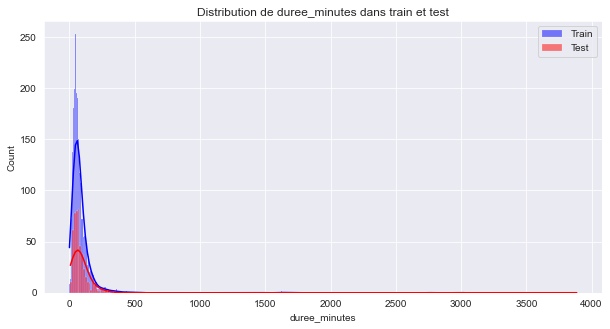

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(y_train, label="Train", color='blue', kde=True)
sns.histplot(y_test, label="Test", color='red', kde=True)
plt.legend()
plt.title("Distribution de duree_minutes dans train et test")
plt.show()

In [30]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 48.94
RMSE : 180.55


In [31]:
categorical_cols = doubs_meteo.select_dtypes(include=['object']).columns
print("Colonnes catégoriques à encoder :", categorical_cols.tolist())

Colonnes catégoriques à encoder : ['hex_id']


In [32]:
X = doubs_meteo.drop(columns=['hex_id', 'duree_minutes'])  # hex_id ignoré, duree_minutes = target
y = doubs_meteo['duree_minutes']
train_hex_ids, test_hex_ids = train_test_split(doubs_meteo['hex_id'].unique(), test_size=0.2, random_state=42)

X_train = X[doubs_meteo['hex_id'].isin(train_hex_ids)]
y_train = y[doubs_meteo['hex_id'].isin(train_hex_ids)]

X_test = X[doubs_meteo['hex_id'].isin(test_hex_ids)]
y_test = y[doubs_meteo['hex_id'].isin(test_hex_ids)]

model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 48.94 minutes
MSE : 32597.91
RMSE : 180.55 minutes
R² : -0.01


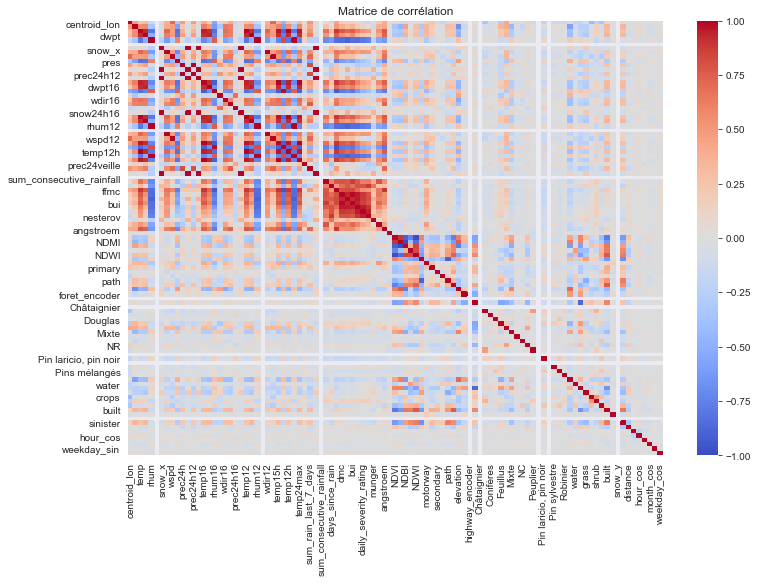

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=False)
plt.title("Matrice de corrélation")
plt.show()

Features trop corrélées à supprimer : {'sum_snow_last_7_days', 'wdir12', 'snow24h16', 'temp24max', 'temp12', 'bui', 'temp15h', 'dwpt', 'rhum15h', 'temp16', 'ffmc', 'nesterov', 'NDBI', 'wspd12', 'dwpt16', 'snow24h12', 'temp12h', 'NDWI', 'snow24h', 'isi', 'daily_severity_rating', 'dwpt12', 'rhum16', 'rhum12', 'fwi', 'prec24h12', 'rhum12h'}


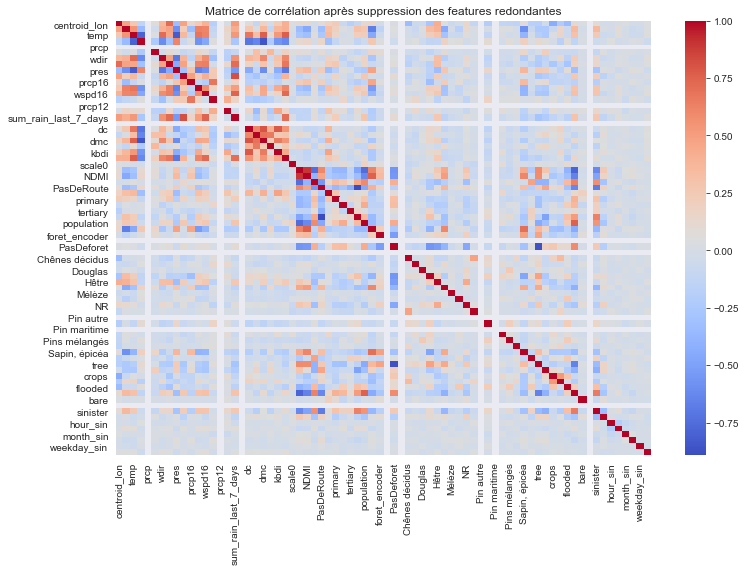

In [34]:
corr_matrix = X_train.corr().abs()

high_corr_features = set()
threshold = 0.9

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)

print(f"Features trop corrélées à supprimer : {high_corr_features}")

X_train = X_train.drop(columns=high_corr_features, errors='ignore').copy()
X_test = X_test.drop(columns=high_corr_features, errors='ignore').copy()

plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=False)
plt.title("Matrice de corrélation après suppression des features redondantes")
plt.show()

In [35]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 47.38 minutes
MSE : 32224.22
RMSE : 179.51 minutes
R² : -0.00


In [36]:
X_train.shape

(2181, 74)

          Feature  Importance
70      month_sin    0.099554
47             NC    0.067043
66       sinister    0.064987
48             NR    0.047600
46         Mélèze    0.046485
..            ...         ...
55       Robinier    0.000000
36  foret_encoder    0.000000
52   Pin maritime    0.000000
39    Châtaignier    0.000000
50      Pin autre    0.000000

[73 rows x 2 columns]


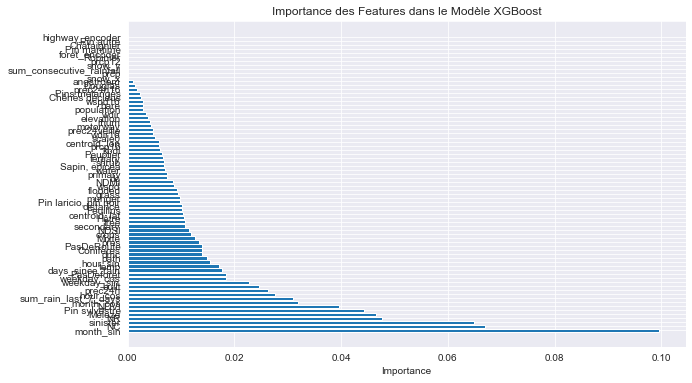

In [37]:
importances = model.feature_importances_

features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(73))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Importance des Features dans le Modèle XGBoost')
plt.show()

In [38]:
threshold = 0.01

important_features = importance_df[importance_df['Importance'] > threshold]['Feature']

# Afficher les features importantes
print(f"Features importantes (importance > {threshold}) : {important_features.tolist()}")

X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

print(f"Dimensions après réduction : {X_train_reduced.shape}")

Features importantes (importance > 0.01) : ['month_sin', 'NC', 'sinister', 'NR', 'Mélèze', 'Pin sylvestre', 'NDVI', 'month_cos', 'sum_rain_last_7_days', 'hour_cos', 'prec24h', 'built', 'weekday_sin', 'weekday_cos', 'PasDeforet', 'days_since_rain', 'temp', 'hour_sin', 'path', 'dmc', 'Conifères', 'PasDeRoute', 'pres', 'Mixte', 'crops', 'NDSI', 'secondary', 'tree', 'Hêtre', 'centroid_lat', 'Feuillus', 'distance']
Dimensions après réduction : (2181, 32)


In [39]:
correlation_matrix = X_train_reduced.corr().abs()

to_drop = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > 0.9:
            feature = correlation_matrix.columns[i]
            to_drop.add(feature)

X_train_final = X_train_reduced.drop(columns=to_drop)
X_test_final = X_test_reduced.drop(columns=to_drop)

print(f"Dimensions après suppression des corrélations élevées : {X_train_final.shape}")

Dimensions après suppression des corrélations élevées : (2181, 32)


In [40]:
model = LinearRegression()
model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae} minutes")
print(f"MSE : {mse}")
print(f"RMSE : {rmse} minutes")
print(f"R² : {r2}")


MAE : 44.251229002791426 minutes
MSE : 32306.791813187494
RMSE : 179.74090189266187 minutes
R² : -0.0045413709185087026


In [41]:
'''param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 10],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train_final, y_train)

print("Meilleurs hyperparamètres : ", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_final)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best, squared=False)
r2_best = r2_score(y_test, y_pred_best)

print(f"MAE (Optimisé) : {mae_best} minutes")
print(f"MSE (Optimisé) : {mse_best}")
print(f"RMSE (Optimisé) : {rmse_best} minutes")
print(f"R² (Optimisé) : {r2_best}'''

print("53m 48s // Meilleurs hyperparamètres :  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.8} MAE (Optimisé) : 45.2282370601792 minutes MSE (Optimisé) : 31756.41117306734 RMSE (Optimisé) : 178.20328608941907 minutes R² (Optimisé) : 0.012572062255243543")

53m 48s // Meilleurs hyperparamètres :  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.8} MAE (Optimisé) : 45.2282370601792 minutes MSE (Optimisé) : 31756.41117306734 RMSE (Optimisé) : 178.20328608941907 minutes R² (Optimisé) : 0.012572062255243543


In [42]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

xgb_model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train_final, y_train)

print("Meilleurs hyperparamètres : ", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_final)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best, squared=False)
r2_best = r2_score(y_test, y_pred_best)

print(f"MAE (Optimisé) : {mae_best} minutes")
print(f"MSE (Optimisé) : {mse_best}")
print(f"RMSE (Optimisé) : {rmse_best} minutes")
print(f"R² (Optimisé) : {r2_best}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Meilleurs hyperparamètres :  {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}
MAE (Optimisé) : 44.69893915771321 minutes
MSE (Optimisé) : 31645.49352497973
RMSE (Optimisé) : 177.89180286055827 minutes
R² (Optimisé) : 0.01602091495820679


In [43]:
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8],
    'n_estimators': [100, 150, 200]
}

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_absolute_error',
                           verbose=1,
                           n_jobs=-1,
                           )

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f"Meilleurs hyperparamètres : {best_params}")

best_mae = -grid_search.best_score_
print(f"MAE (Optimisé) : {best_mae:.2f} minutes")

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Meilleurs hyperparamètres : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.8}
MAE (Optimisé) : 46.01 minutes


In [44]:
final_model = XGBRegressor(**best_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 44.81 minutes
MSE : 31700.60
RMSE : 178.05 minutes
R² : 0.01


In [48]:
import numpy as np
import pandas as pd

def detect_outliers_iqr(df):
    outlier_counts = {}  # Dictionnaire pour stocker le nombre d'outliers par colonne
    total_outliers = 0   # Compteur global d'outliers
    total_values = np.prod(df.shape)  # Nombre total de valeurs dans le dataset

    for col in df.select_dtypes(include=[np.number]).columns:  # On applique seulement aux colonnes numériques
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Détection des outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        outlier_counts[col] = outlier_count
        total_outliers += outlier_count

    # Calcul du pourcentage d'outliers
    outlier_percentage = (total_outliers / total_values) * 100

    # Affichage des résultats
    print("Nombre d'outliers par colonne :")
    for col, count in outlier_counts.items():
        print(f"{col}: {count} outliers")

    print(f"\nNombre total d'outliers : {total_outliers}")
    print(f"Pourcentage d'outliers : {outlier_percentage:.2f}%")

    return outlier_counts, outlier_percentage

# Appliquer la fonction à ton dataset
outliers, outlier_pct = detect_outliers_iqr(X_train)

Nombre d'outliers par colonne :
centroid_lon: 0 outliers
centroid_lat: 5 outliers
temp: 0 outliers
rhum: 90 outliers
prcp: 0 outliers
snow_x: 38 outliers
wdir: 469 outliers
wspd: 0 outliers
pres: 3 outliers
prec24h: 378 outliers
prcp16: 493 outliers
wdir16: 0 outliers
wspd16: 13 outliers
prec24h16: 31 outliers
prcp12: 0 outliers
prec24veille: 239 outliers
sum_rain_last_7_days: 443 outliers
sum_consecutive_rainfall: 0 outliers
dc: 393 outliers
days_since_rain: 204 outliers
dmc: 258 outliers
munger: 490 outliers
kbdi: 431 outliers
angstroem: 0 outliers
scale0: 0 outliers
NDVI: 57 outliers
NDMI: 10 outliers
NDSI: 12 outliers
PasDeRoute: 0 outliers
motorway: 218 outliers
primary: 36 outliers
secondary: 37 outliers
tertiary: 6 outliers
path: 38 outliers
population: 361 outliers
elevation: 55 outliers
foret_encoder: 366 outliers
highway_encoder: 0 outliers
PasDeforet: 0 outliers
Châtaignier: 0 outliers
Chênes décidus: 405 outliers
Conifères: 412 outliers
Douglas: 30 outliers
Feuillus: 0 outl